In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from os.path import join, isfile, isdir
from os import listdir

In [2]:
parent_path = "/data/cschmidt/excited_states/data_energy"

n_atoms = 45

In [3]:
# list all the files in the directory
files = [f for f in listdir(parent_path) if isfile(join(parent_path, f))]

# sort the files by their name
files.sort()
print(len(files))

13


train_acetone_s1_energy_osc.dat
0.70002576 1.07033201


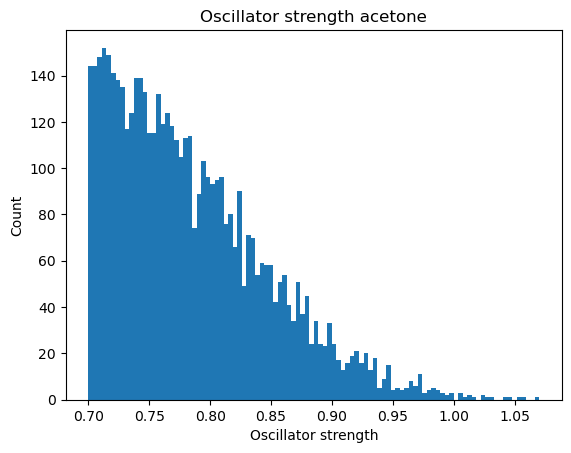

train_acetone_s2_energy_osc.dat
0.70014487 1.05745639


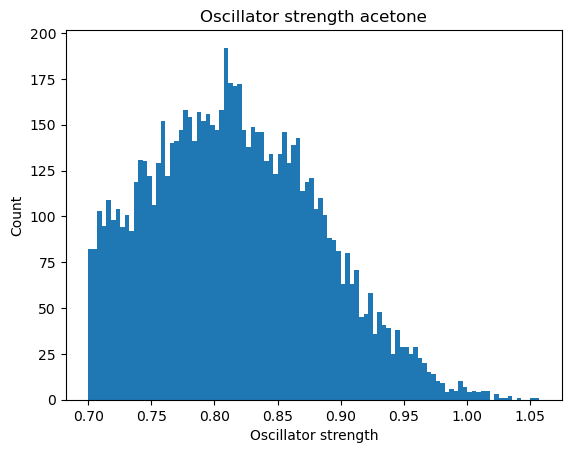

train_acn_s1_energy_osc.dat
0.70006371 1.08585201


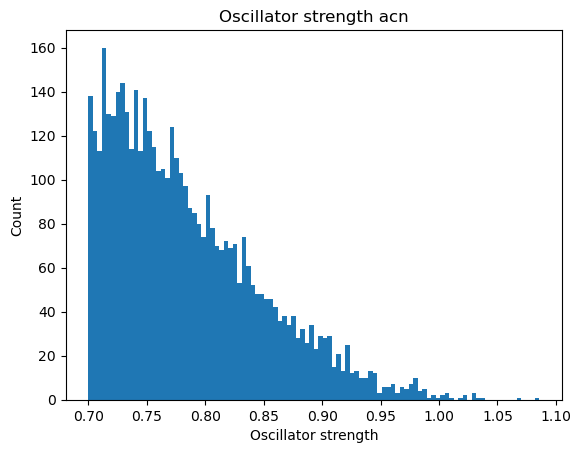

train_acn_s2_energy_osc.dat
0.70010001 1.06629185


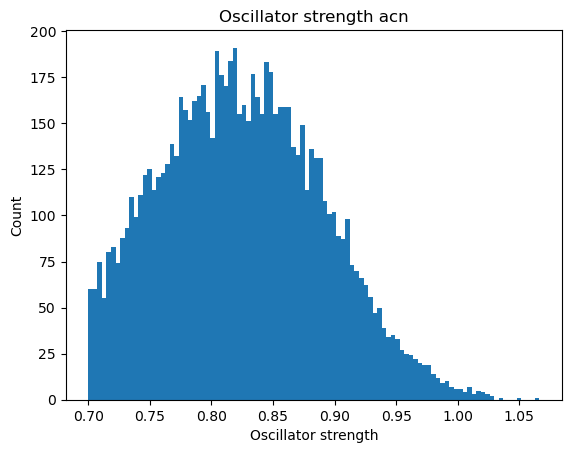

train_all_sol_energy_osc.dat
0.70000712 1.13721978


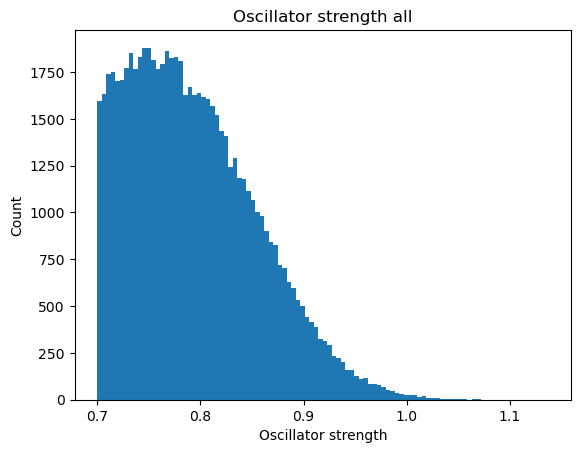

train_dcm_s1_energy_osc.dat
0.70004063 1.0221278


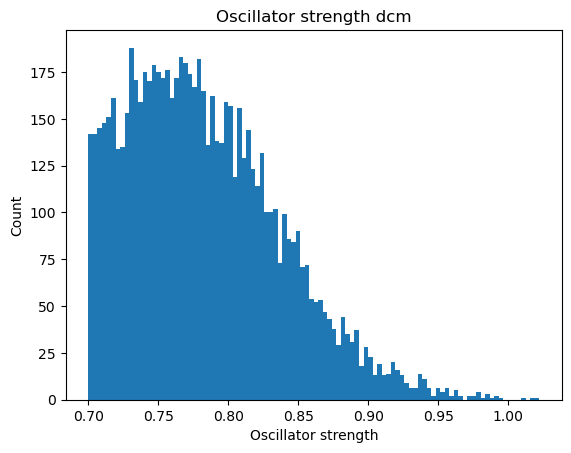

train_dcm_s2_energy_osc.dat
0.70001349 1.03029308


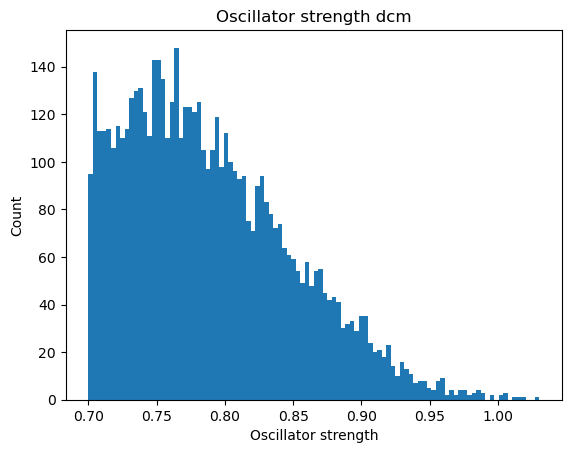

train_dmso_s1_energy_osc.dat
0.7000588 1.03565444


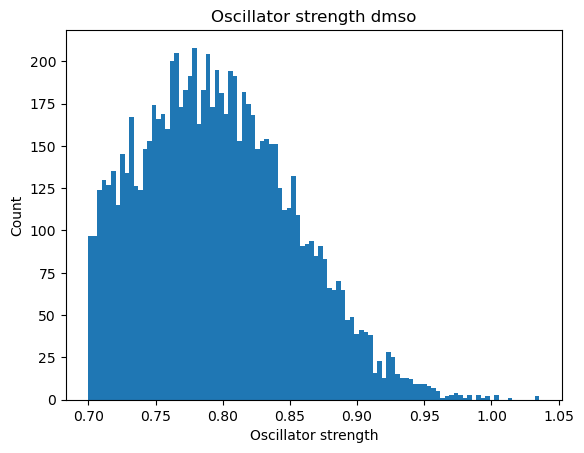

train_dmso_s2_energy_osc.dat
0.70000712 1.06933891


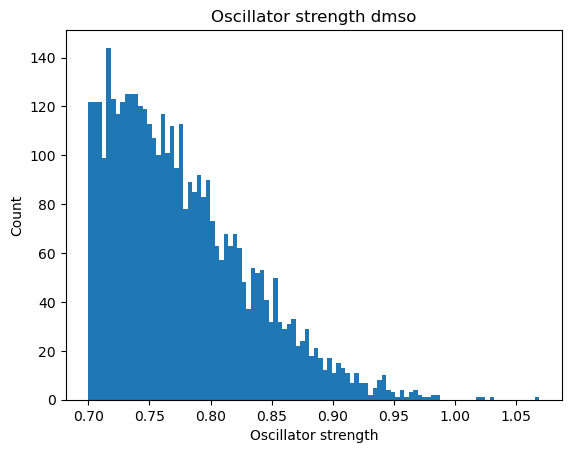

train_methanol_s1_energy_osc.dat
0.70007363 0.99744755


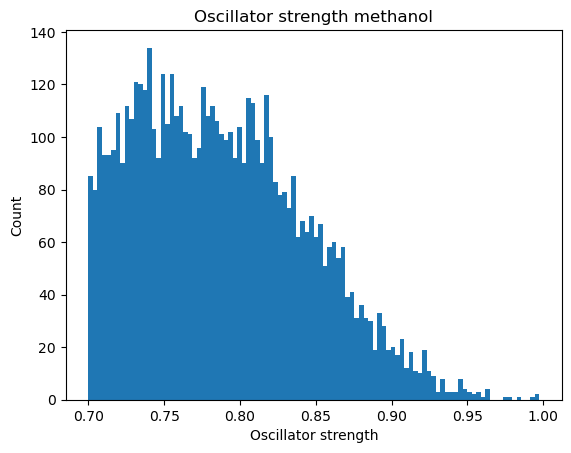

train_methanol_s2_energy_osc.dat
0.70004208 1.00445592


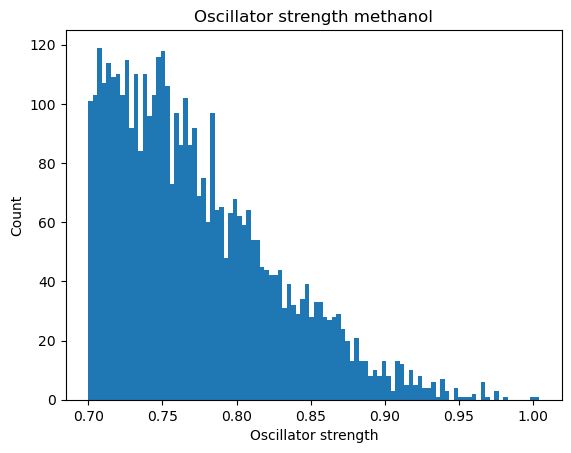

train_water_s1_energy_osc.dat
0.70009993 1.13721978


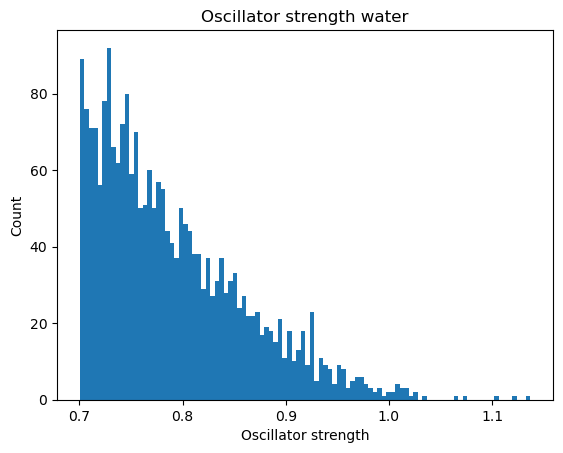

train_water_s2_energy_osc.dat
0.70005141 0.99624679


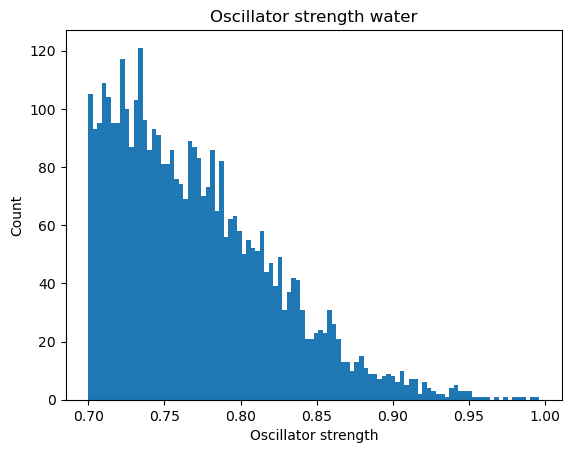

In [4]:
# extract the energies and oscillator strenghts from the files
for file in files:
    # read the file
    with open(join(parent_path, file), "r") as f:
        lines = f.readlines()

    filename = file.split("_")[1]

    # extract the energies and oscillator strengths
    # the first line of the excitation block contains the excitation energy and the oscillator strength
    # the following n_atoms are just the coordinates + 1 empty line
    energies = []
    oscillator_strengths = []

    # extract the energies and oscillator strengths
    for i in range(len(lines)):
        if i % (n_atoms + 2) == 0:
            if lines[i].strip():
                energy, osc_strength = lines[i].strip().split()
                energy, osc_strength = float(energy), float(osc_strength)
                energies.append(energy), oscillator_strengths.append(osc_strength)

    print(file)
    print(min(oscillator_strengths), max(oscillator_strengths))
    # plot the oscillator strength as histogram
    plt.hist(oscillator_strengths, bins=100)
    plt.xlabel("Oscillator strength")
    plt.ylabel("Count")
    plt.title(f"Oscillator strength {filename}")
    plt.show()